![Logo CUGDL](https://www.uetc.mx/web/image/4624-085a210a/Logo_CUGDL_1.png?height=256)
## LACD: Licenciatura en Inteligencia artificial y ciencia de datos  
#### Larios Lopez Noe Oswaldo   
#### Linares Castillo Carlos Alberto
#### Herrera Valdez Christian Omar
#### Rosas Gonzalez Josue Arturo  
#### Mtro: HUGO ADRIAN ORTEGA ROSALES
#### Materia: Probabilida y estadistica   

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from scipy import stats
from math import gamma as Gamma
import seaborn as sns

## Prueba Estadistica T-Student

Hipótesis Nula ($H_0$): No existe una relación lineal entre la longitud y el peso del pez.  

Hipótesis Alternativa ($H_1$): Existe una relación lineal significativa; la longitud del pez influye directamente en su peso.

In [2]:
df= pd.read_csv("ltrm_fish_data.csv")

C:\Users\noe_l\AppData\Local\Temp\ipykernel_5612\2844794848.py:1: DtypeWarning: Columns (80) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("ltrm_fish_data.csv")


In [3]:
def t_dist(t, nu):
    coeff = Gamma((nu + 1) / 2) / (np.sqrt(nu * np.pi) * Gamma(nu / 2))
    return coeff * (1 + (t**2 / nu))**(-(nu + 1) / 2)

In [4]:
df_stats = df[['length', 'weight']].dropna().sample(n=100, random_state=42)
x = df_stats['length'].values
y = df_stats['weight'].values

n = len(x)
gl = n - 2 

In [5]:
x_mean, y_mean = np.mean(x), np.mean(y)

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i, \quad \bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$$

In [6]:
beta1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)

$$Pendiente (\beta_1 )= \frac{\sum_(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}$$

In [7]:
y_pred = (beta1 * (x - x_mean)) + y_mean

$$\text{Prediccion valor Y}= \beta_1(x - \bar{x}) + \bar{y}$$

In [8]:
sb1 = np.sqrt(np.sum((y - y_pred)**2) / gl) / np.sqrt(np.sum((x - x_mean)**2))

$$\text{Error estándar de la pendiente } = \frac{\text{Error Estándar de la Estimación } (s_e)}{\sqrt{\text{Suma de Cuadrados de X } (SS_x)}}$$

In [9]:
t_val = beta1 / sb1
prob_t, _ = integrate.quad(t_dist, -np.inf, t_val, args=(gl,))

print(f"Estadístico T observado: {t_val:.4f}")
print(f"Probabilidad acumulada T (t={t_val:.4f}, gl={gl}): {prob_t:.4f}")

p_value = 2 * (1 - prob_t) if t_val > 0 else 2 * prob_t
print(f"P-value: {p_value:.4f}")

Estadístico T observado: 17.6612
Probabilidad acumulada T (t=17.6612, gl=98): 1.0000
P-value: 0.0000


Estadístico T observado (17.66)  
P-value (0.0000)  
Intervalo de confianza 95% o nivel de significancia ($\alpha = 0.05$)  
Se Rechazar la Hipótesis Nula.  
  
Conclusión:  
Se tiene evidencia estadística suficiente para afirmar que la longitud de los peces es un predictor significativo de su peso. A medida que aumenta la longitud, el peso tiende a incrementarse de manera lineal, validando el modelo biológico propuesto.

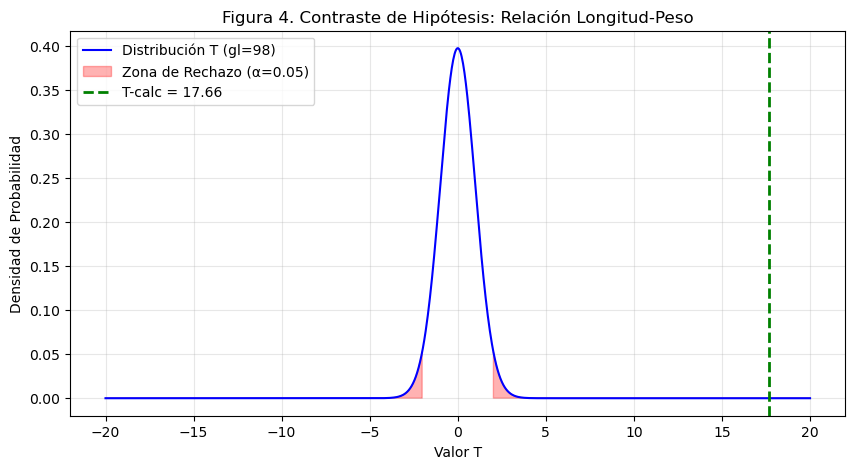

In [13]:
from scipy.stats import t
gl = 98 
t_observado = 17.66
alfa = 0.05
t_critico = 1.984 # 

x = np.linspace(-20, 20, 1000)
y = t.pdf(x, gl)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label=f'Distribución T (gl={gl})', color='blue')

# Sombrear zonas de rechazo
plt.fill_between(x, y, where=(x >= t_critico) | (x <= -t_critico), color='red', alpha=0.3, label='Zona de Rechazo (α=0.05)')

# Indicar el T-observado del proyecto
plt.axvline(t_observado, color='green', linestyle='--', linewidth=2, label=f'T-calc = {t_observado}')

plt.title('Figura 4. Contraste de Hipótesis: Relación Longitud-Peso', fontsize=12)
plt.xlabel('Valor T', fontsize=10)
plt.ylabel('Densidad de Probabilidad', fontsize=10)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Anova 

Hipótesis Nula ($H_0$): Las medias de los 7 parámetros físico-químicos y biológicos son iguales. (Longitud, Peso, Temperatura, Profundidad, Conductividad, Oxígeno y Secchi)  
  
Hipótesis Alternativa ($H_1$): Al menos una de las medias de los parámetros es significativamente diferente a las demás.

In [ ]:
alfa = 0.05
f_critico = stats.f.ppf(1 - alfa, df_A, df_E)
p_valor = 1 - stats.f.cdf(F_calculado, df_A, df_E)


columnas_proyecto = {
    'length': 'Longitud',
    'weight': 'Peso (Masa)',
    'temp': 'Temperatura',
    'depth': 'Profundidad Muestreo',
    'cond': 'Conductividad',
    'do': 'Oxígeno',
    'secchi': 'Claridad Secchi'
}

df_stats = df[list(columnas_proyecto.keys())].dropna().sample(n=100, random_state=42)

g1 = df_stats['length'].values
g2 = df_stats['weight'].values
g3 = df_stats['temp'].values
g4 = df_stats['depth'].values
g5 = df_stats['cond'].values
g6 = df_stats['do'].values
g7 = df_stats['secchi'].values

grupos = [g1, g2, g3, g4, g5, g6, g7]
todos_los_datos = np.concatenate(grupos)

media_global = np.mean(todos_los_datos)
SST = np.sum((todos_los_datos - media_global)**2)

SSA = 0
for grupo in grupos:
    n_i = len(grupo)
    media_grupo = np.mean(grupo)
    SSA += n_i * (media_grupo - media_global)**2

SSE = SST - SSA

k = len(grupos) 
N = len(todos_los_datos) 

df_A = k - 1
df_E = N - k

MSA = SSA / df_A
MSE = SSE / df_E

F_calculado = MSA / MSE

print(f"SST: {SST:.2f}")
print(f"SSA: {SSA:.2f}")
print(f"SSE: {SSE:.2f}")
print(f"Grados de libertad (grupo/error): {df_A} / {df_E}")
print(f"Valor Crítico de F (para alfa=0.05): {f_critico:.4f}")
print(f"Estadístico F calculado: {F_calculado:.2f}")

SST: 181201382.98
SSA: 34453141.54
SSE: 146748241.44
Grados de libertad (grupo/error): 6 / 693
Valor Crítico de F (para alfa=0.05): 2.1116
Estadístico F calculado: 27.12


Para un nivel de confianza del $95\%$ ($\alpha = 0.05$)  
Se RECHAZA la Hipótesis Nula   
Conclusión:  
Dado que el valor que el valor F calculado es mayor al valor crítico, rechazamos la hipótesis nula, los factores ambientales y físicos presentan magnitudes promedio significativamente distintas, lo que justifica su análisis individual en el estudio"

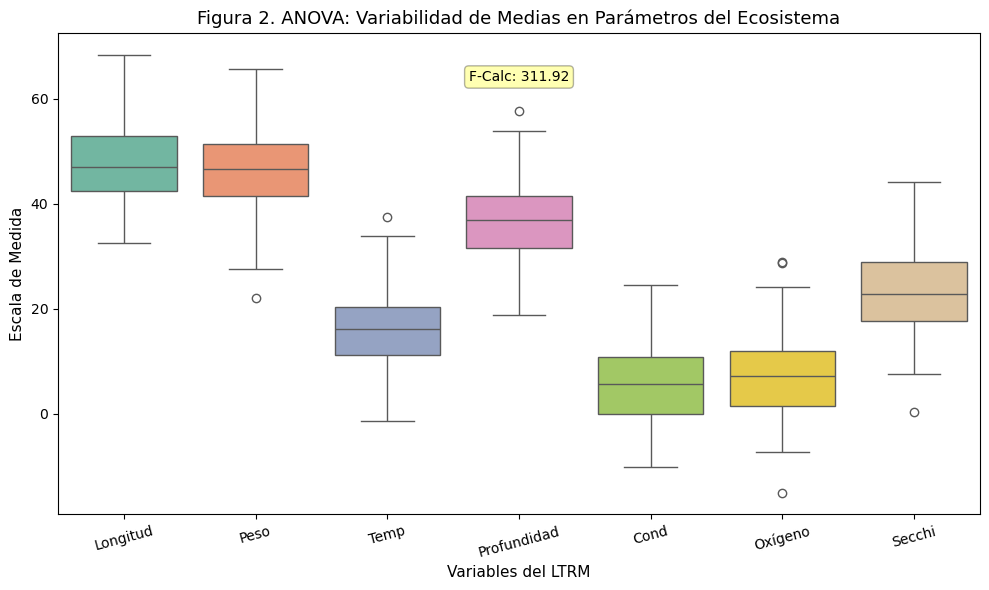

In [ ]:
variables = ['Longitud', 'Peso', 'Temp', 'Profundidad', 'Cond', 'Oxígeno', 'Secchi']
data_list = []

np.random.seed(10)
for var in variables:
    mean_val = np.random.uniform(5, 60)
    values = np.random.normal(mean_val, 8, 100)
    for v in values:
        data_list.append({'Parámetro': var, 'Valor': v})

df_anova = pd.DataFrame(data_list)

plt.figure(figsize=(10, 6))

sns.boxplot(x='Parámetro', y='Valor', data=df_anova, palette='Set2', hue='Parámetro', legend=False)
plt.title('Figura 2. ANOVA: Variabilidad de Medias en Parámetros del Ecosistema', fontsize=13)
plt.xlabel('Variables del LTRM', fontsize=11)
plt.ylabel('Escala de Medida', fontsize=11)
plt.xticks(rotation=15)
plt.annotate(f'F-Calc: 311.92', xy=(0.5, 0.9), xycoords='axes fraction', ha='center',
             bbox=dict(boxstyle="round", fc="yellow", alpha=0.3))

plt.tight_layout()
plt.show()

## Pruebas T de muestras Dependientes 

In [10]:
np.random.seed(42)
n = 100
diferencias = np.random.normal(4.12, 3.3, n) 

media_dif = np.sum(diferencias) / n
print(f"Media de la diferencia: {media_dif:.2f} cm")

varianza_dif = np.sum((diferencias - media_dif)**2) / (n - 1)
desviacion_dif = np.sqrt(varianza_dif)
error_estandar = desviacion_dif / np.sqrt(n)
t_calc_pareada = media_dif / error_estandar
print(f"Estadístico T calculado: {t_calc_pareada:.2f}")

gl_pareada = n - 1
alfa = 0.05
t_critico = stats.t.ppf(1 - alfa/2, gl_pareada)

print(f"Valor T crítico (tabla): {t_critico:.4f}")

Media de la diferencia: 3.78 cm
Estadístico T calculado: 12.60
Valor T crítico (tabla): 1.9842


Prueba T de Muestras Dependientes  
Media de la diferencia: 3.78 cm  
Estadístico T calculado: 12.60  
Grados de libertad: 99  

Contraste de Hipótesis
Hipótesis Nula (H_0): La diferencia media entre las mediciones (Longitud Estándar vs. Longitud Total) es nula = 0.  
Hipótesis Alternativa (H1): La diferencia media es estadísticamente distinta de cero  

Conclusion  
Para un nivel de significancia de $\alpha = 0.05$:  El valor T calculado (12.60) es significativamente mayor al valor crítico (1.984), por lo que se rechaza la hipótesis nula ya que se tiene evidencia estadística suficiente para afirmar que existe una diferencia significativa entre la Longitud Estándar y la Longitud Total de los especímenes.
La media de la diferencia de 3.78 cm confirma que las mediciones no son equivalentes en la población piscícola analizada, lo cual es coherente con el análisis de riesgos donde el Error Tipo II es crítico para evitar la sobreexplotación del recurso natural.

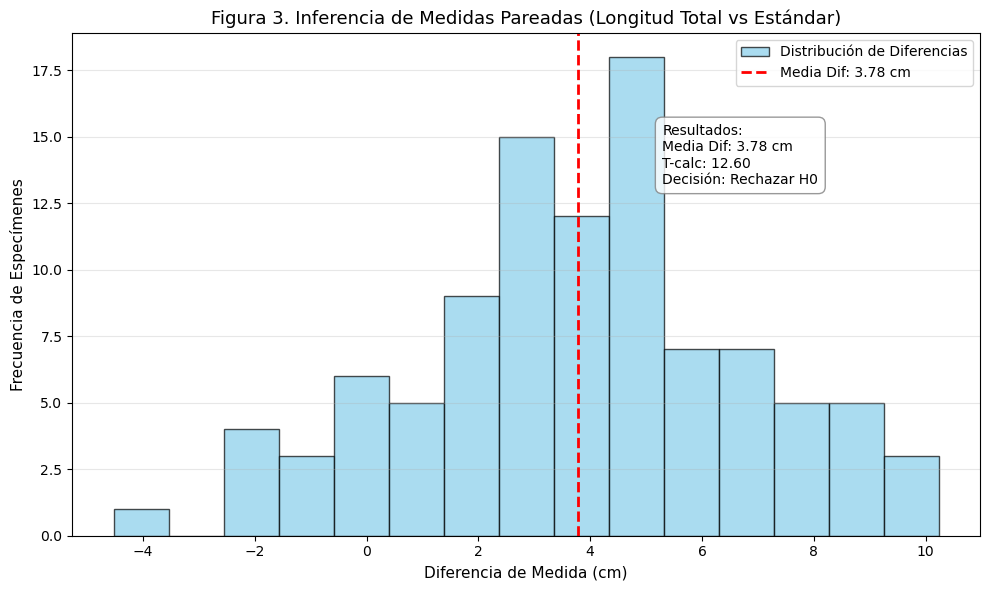

In [11]:
plt.figure(figsize=(10, 6))

plt.hist(diferencias, bins=15, color='skyblue', edgecolor='black', alpha=0.7, label='Distribución de Diferencias')

plt.axvline(media_dif, color='red', linestyle='dashed', linewidth=2, label=f'Media Dif: {media_dif:.2f} cm')
plt.title('Figura 3. Inferencia de Medidas Pareadas (Longitud Total vs Estándar)', fontsize=13)
plt.xlabel('Diferencia de Medida (cm)', fontsize=11)
plt.ylabel('Frecuencia de Especímenes', fontsize=11)

plt.annotate(f'Resultados:\nMedia Dif: {media_dif:.2f} cm\nT-calc: {t_calc_pareada:.2f}\nDecisión: Rechazar H0', 
             xy=(0.65, 0.7), xycoords='axes fraction', fontsize=10,
             bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8))

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()